### Many controls variants are within the 80k dataset: 
- Who many are within the current 80k BCalm results?

#### Planed Process: 
- Load Variant BCalm results
- Get all the controls results and count how many per label

In [1]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_unified_variant_map_again = False
write_output = False

In [3]:
# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

In [5]:
input_variants = "variants_metadata_bcalm_2025"
input_variants = "variants_metadata_bcalm_2025_bbmap"
input_variants = "variants_metadata_bcalm_2025_bbmap_scrambled"


variant_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_variants], sep="\t", low_memory=False)
# # use results of bbmap
# variant_bcalm_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df['ALT'].str.contains("cardiac_neuro_cava_random")]
# # Apply the safe_eval function to the specified columns
# variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df[col_variant_pos].apply(safe_eval)

In [6]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,NaN,9.364095e-06,1.086994,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,-0.664178,1.000000e+00,-0.675062,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,-0.011245,1.000000e+00,-0.028705,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,[136],True,0.101141,0.229206,1.000000,-0.322271,1.000000e+00,-0.106460,C_positive_heart_CAD
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,[136],True,0.222166,-0.468693,0.000576,-1.130559,1.863777e-11,-1.557981,C_positive_heart_CAD
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,[136],True,0.518546,0.246189,1.000000,-0.240604,1.000000e+00,0.009369,C_positive_heart_CAD
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,[136],True,0.812184,0.128220,0.576842,-0.758037,1.000000e+00,-0.630269,C_positive_heart_CAD


In [7]:
variant_bcalm_metadata_df['label'] = variant_bcalm_metadata_df['ID'].apply(hf.get_label)

In [15]:
control_variant_bcalm_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df['label'] != "cardiac_neuro_cava_random"].copy()

In [16]:
control_variant_bcalm_result_df = control_variant_bcalm_metadata_df.loc[control_variant_bcalm_metadata_df["bcalm_variant_effect_data_exists"]].copy()
control_variant_bcalm_result_df['label'].value_counts()

label
GC_Mendelian_variants    164
GC_Selvarajan             99
C_positive_heart_CAD      43
GC_Atrial_fib             15
GC_Mohlke                 11
GC_Liang                   6
Name: count, dtype: int64

In [22]:
sig_level = 0.1
sig_control_variant_bcalm_result_df = control_variant_bcalm_result_df.loc[control_variant_bcalm_result_df['bcalm_variant_effect_adjusted_p_value'] < sig_level].copy()
sig_control_variant_bcalm_result_df['label'].value_counts()

label
GC_Mendelian_variants    6
GC_Atrial_fib            1
GC_Selvarajan            1
Name: count, dtype: int64

In [23]:
print(f"Fraction of significant control variants: {round(sig_control_variant_bcalm_result_df.shape[0] / control_variant_bcalm_result_df.shape[0]*100,1)}%")

Fraction of significant control variants: 2.4%


In [33]:
def plot_volcano(MPRAlm_table, title, logFC_col, adj_p_val_col, significants_niveau=0.1, ylim_max=11, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8):
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] > 0) & (MPRAlm_table[adj_p_val_col] < significants_niveau), 'positive', 'neutral')
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] < 0) & (MPRAlm_table[adj_p_val_col] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

    significant_MPRAlm_table = MPRAlm_table[MPRAlm_table[adj_p_val_col] < significants_niveau]
    up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
    down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=MPRAlm_table[logFC_col],y=MPRAlm_table[adj_p_val_col].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down[logFC_col],y=down[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up[logFC_col],y=up[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(-math.log10(significants_niveau),color="grey",linestyle="--")
    plt.title(title)
    plt.legend()
    plt.show()

In [24]:
control_variant_bcalm_result_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label'],
      dtype='object')

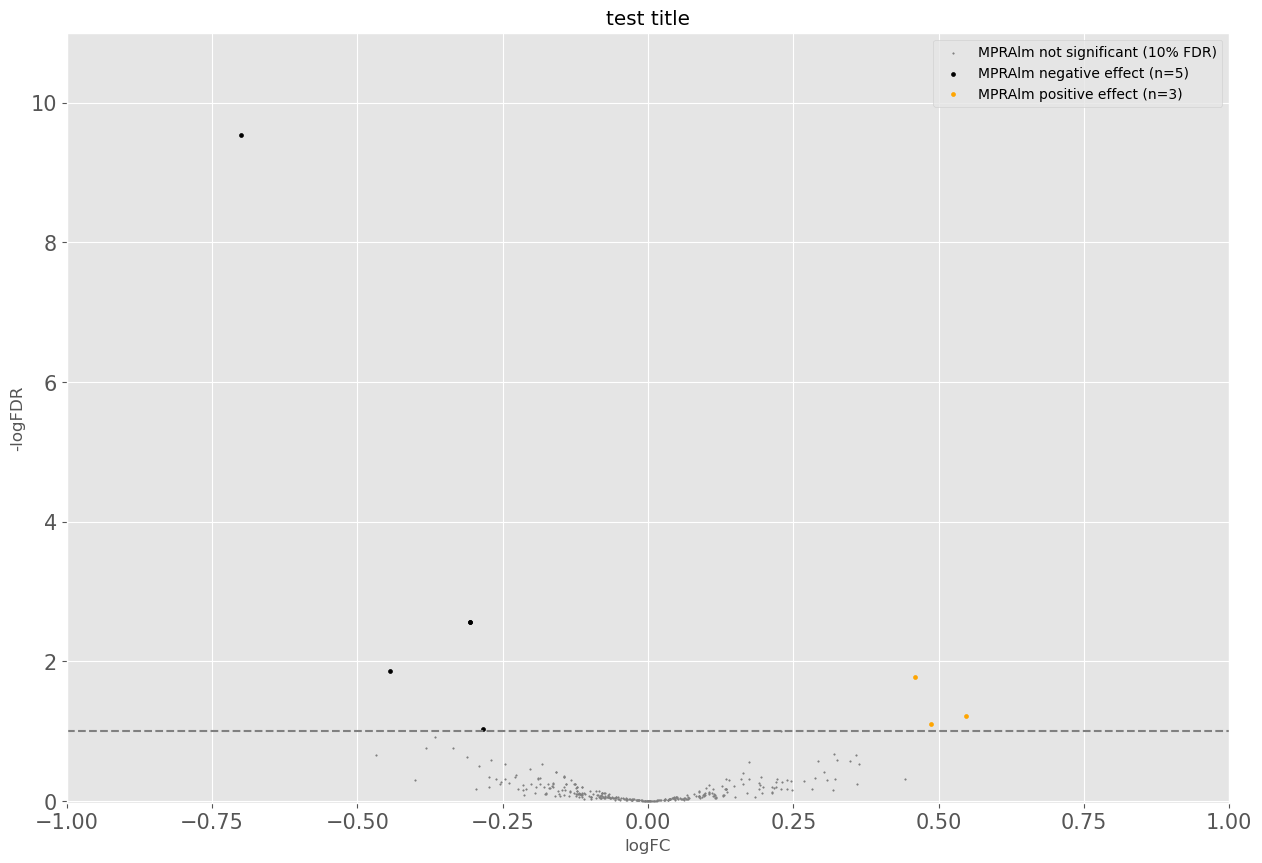

In [34]:
plot_volcano(control_variant_bcalm_result_df, "test title", logFC_col="bcalm_variant_effect_log_ratio_activity", adj_p_val_col="bcalm_variant_effect_adjusted_p_value", significants_niveau=0.1, ylim_max=11, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8)

In [ ]:
sig_control_variant_bcalm_result_df